  LOADING DATA
  Rows     : 2,972
  Columns  : 20
  Nulls    : 0
  Date range: 2015-01-03 → 2024-12-28
  Anomaly % : 55.3%

  EDA SECTION  (11 charts)

[EDA 1] Attack Trends Over Time ...


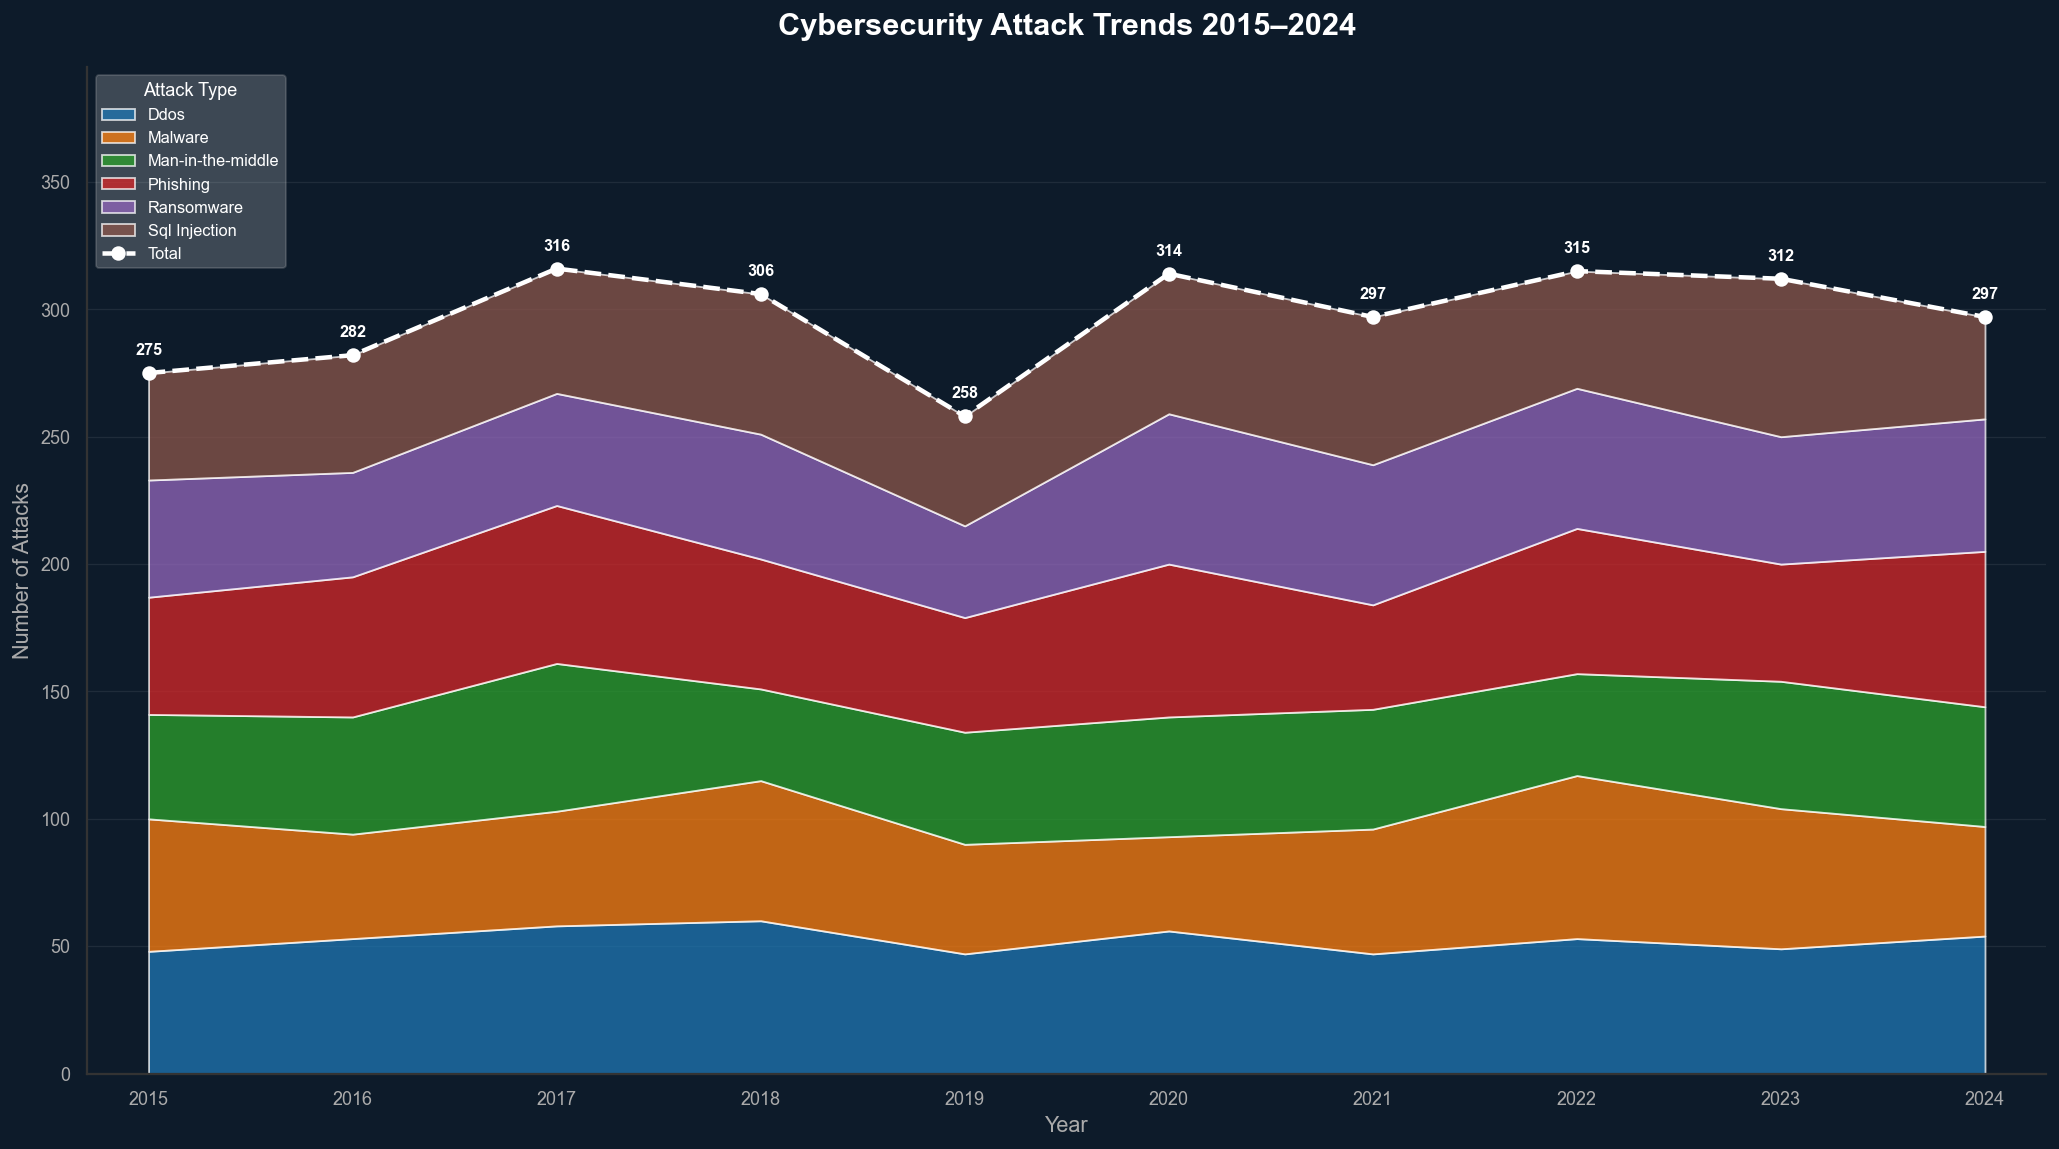

    Saved → plots/01_attack_trends.png
[EDA 2] Attack Type Distribution ...


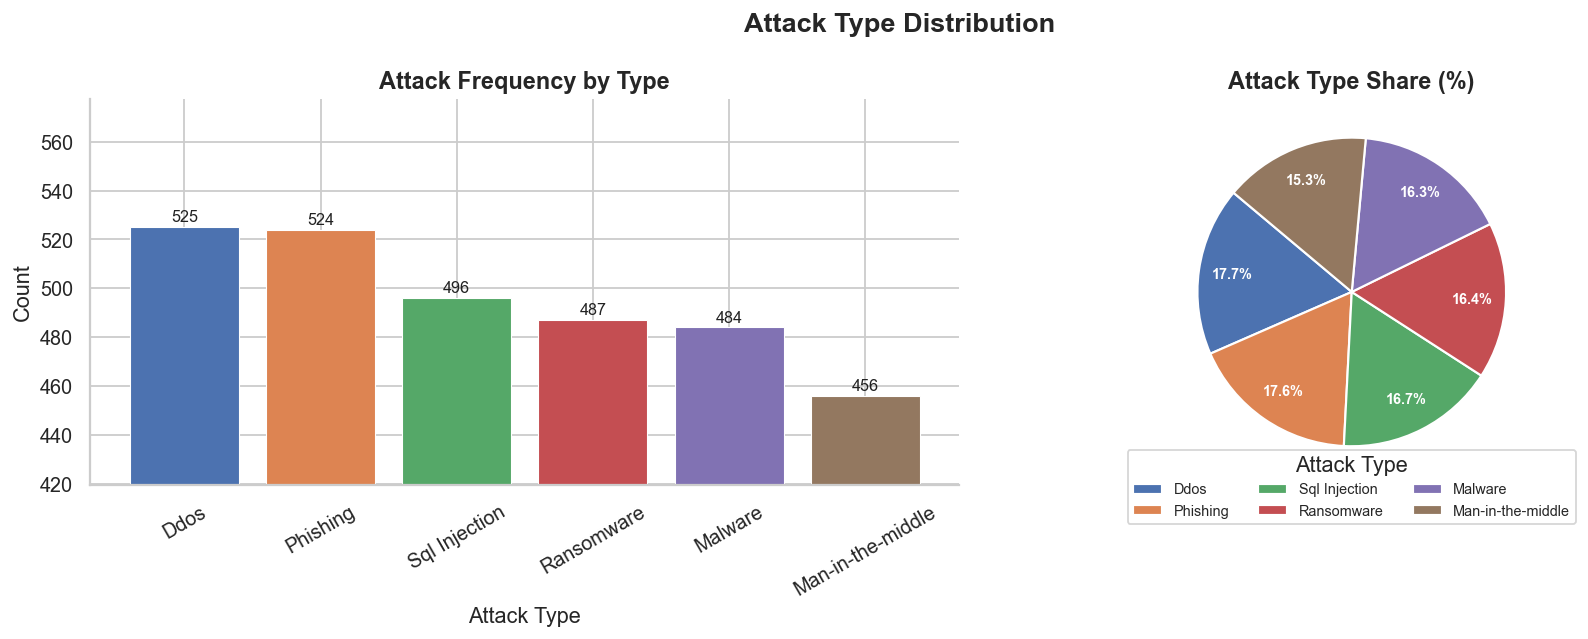

    Saved → plots/02_attack_distribution.png
[EDA 3] Geographic Analysis ...


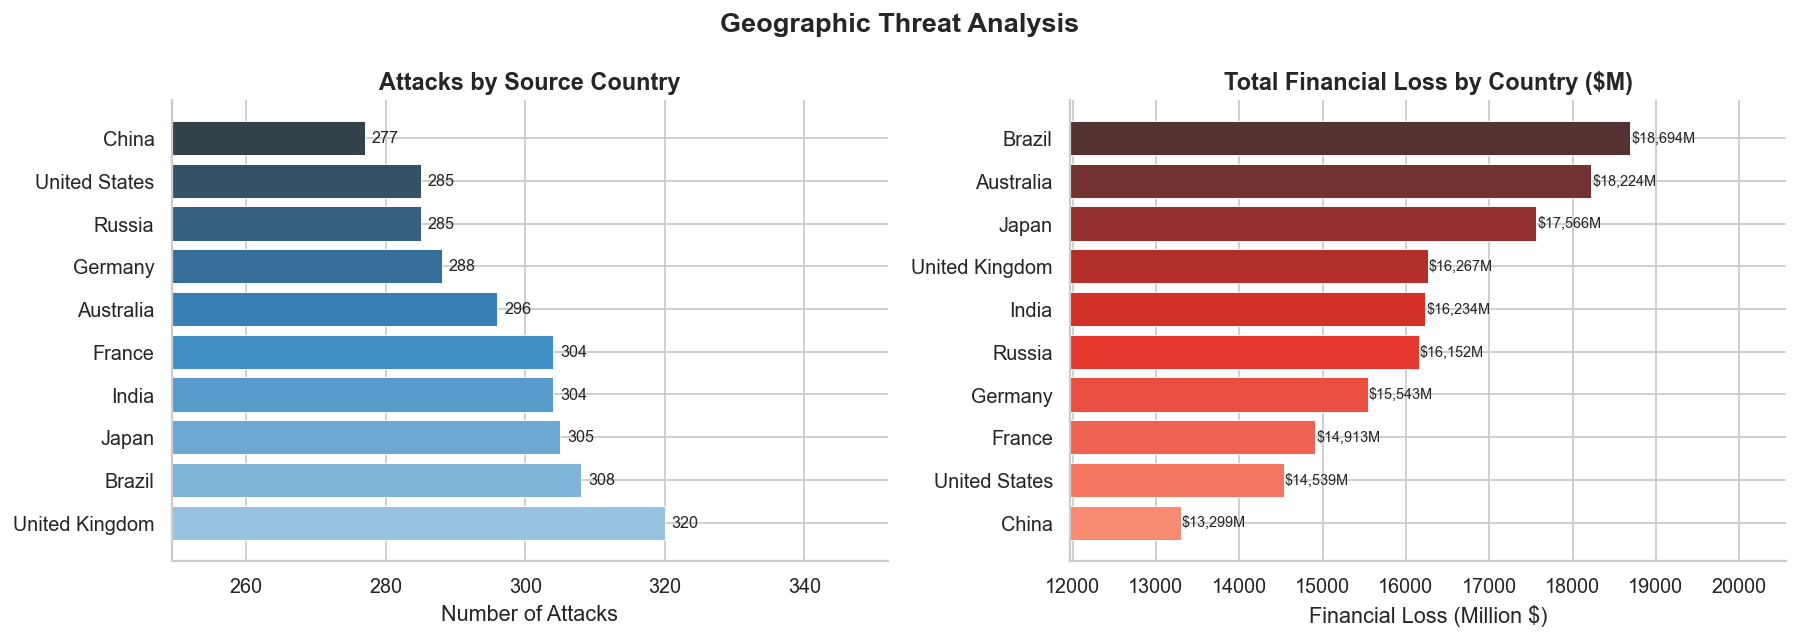

    Saved → plots/03_geographic_analysis.png
[EDA 4] Top 10 Source IPs ...


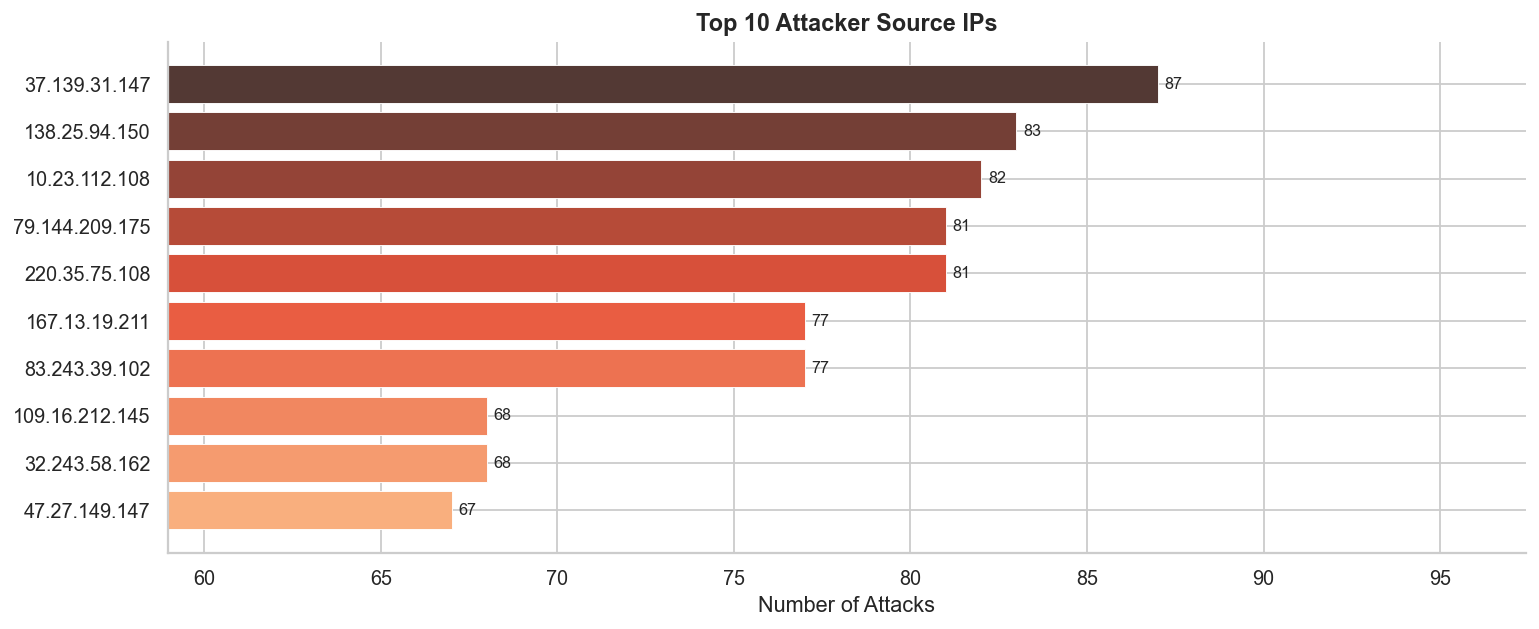

    Saved → plots/04_top_source_ips.png
[EDA 5] Targeted Ports & Protocols ...


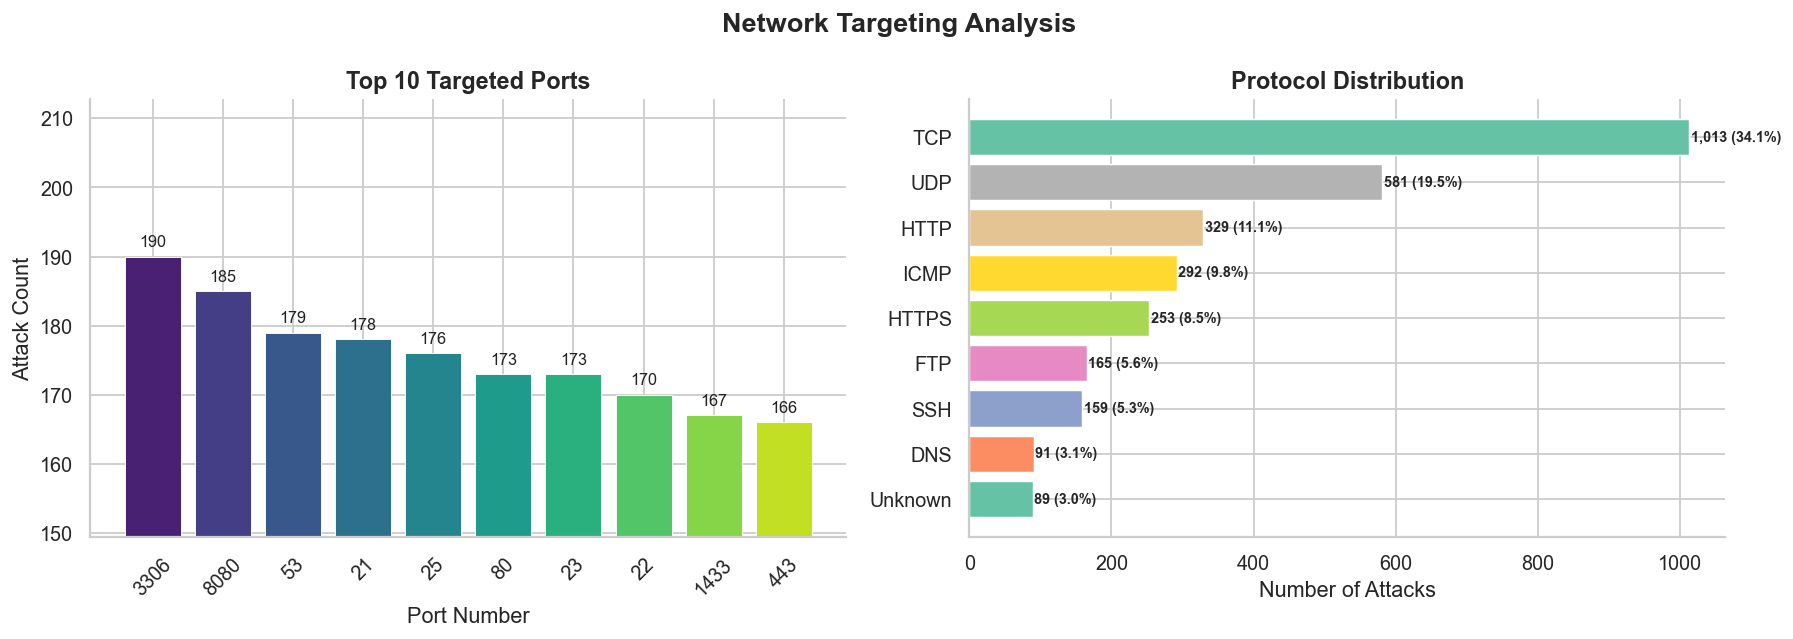

    Saved → plots/05_ports_protocols.png
[EDA 6] Industry Targeting ...


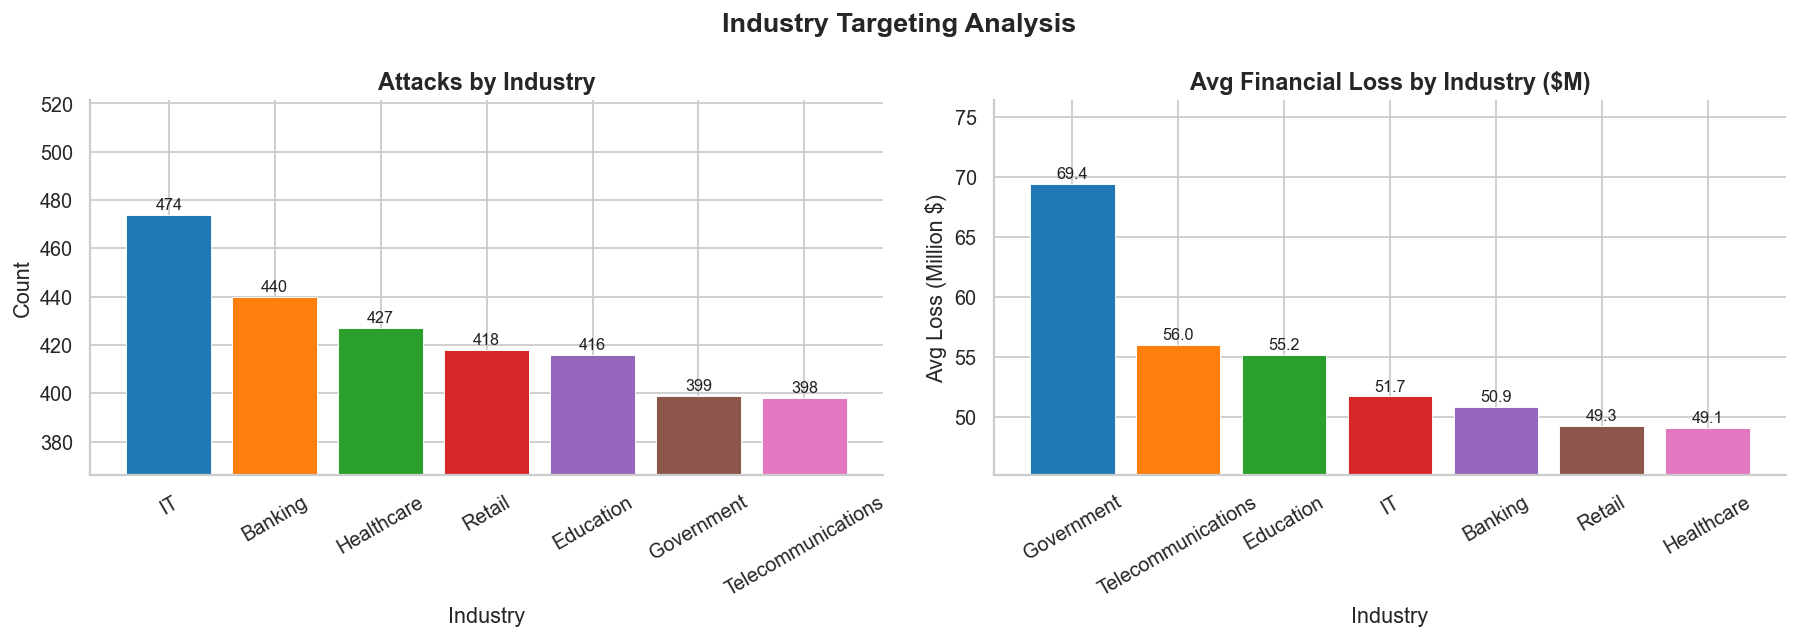

    Saved → plots/06_industry_analysis.png
[EDA 7] Financial Impact Analysis ...


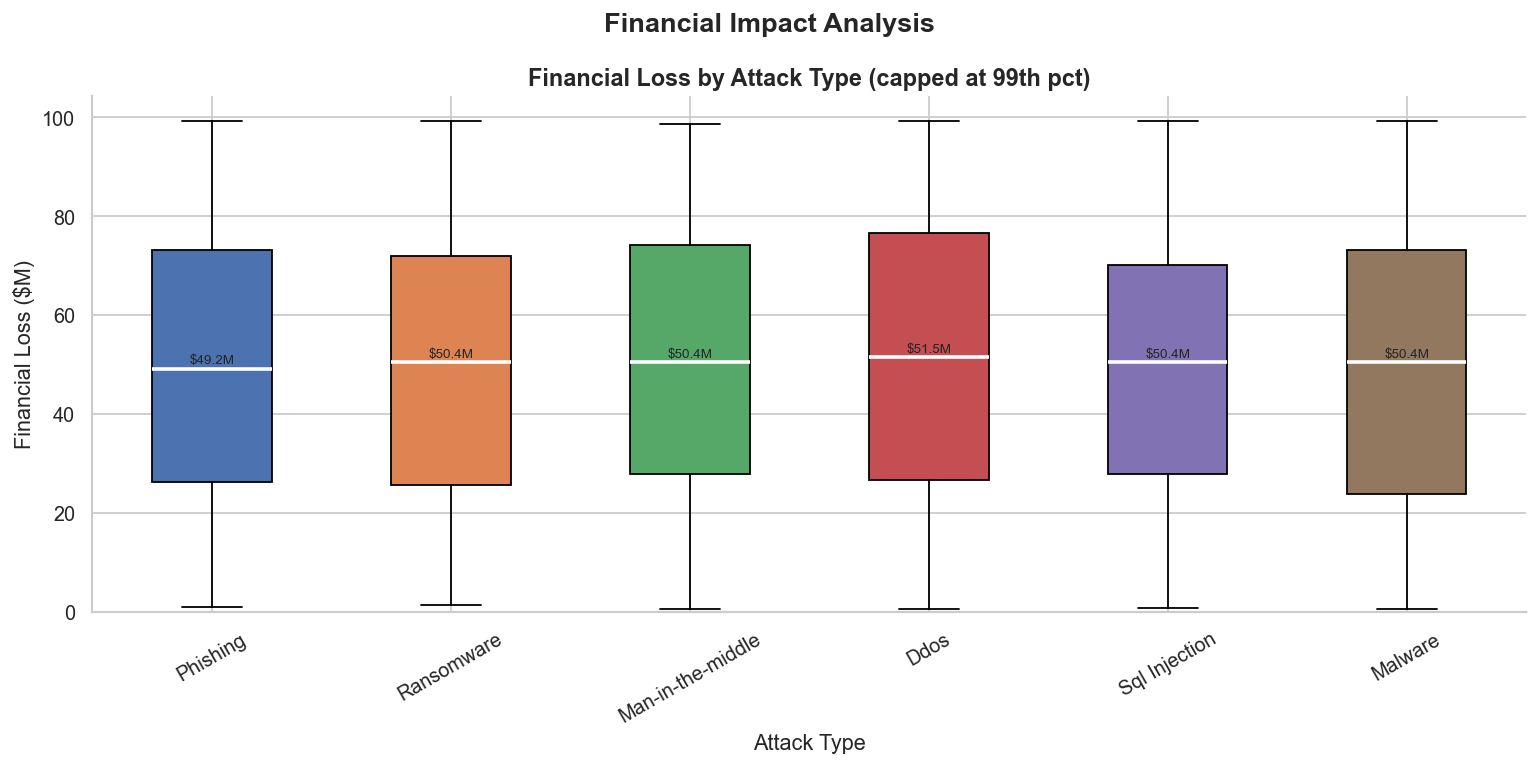

    Saved → plots/07_financial_impact.png
[EDA 8] Resolution Time Analysis ...


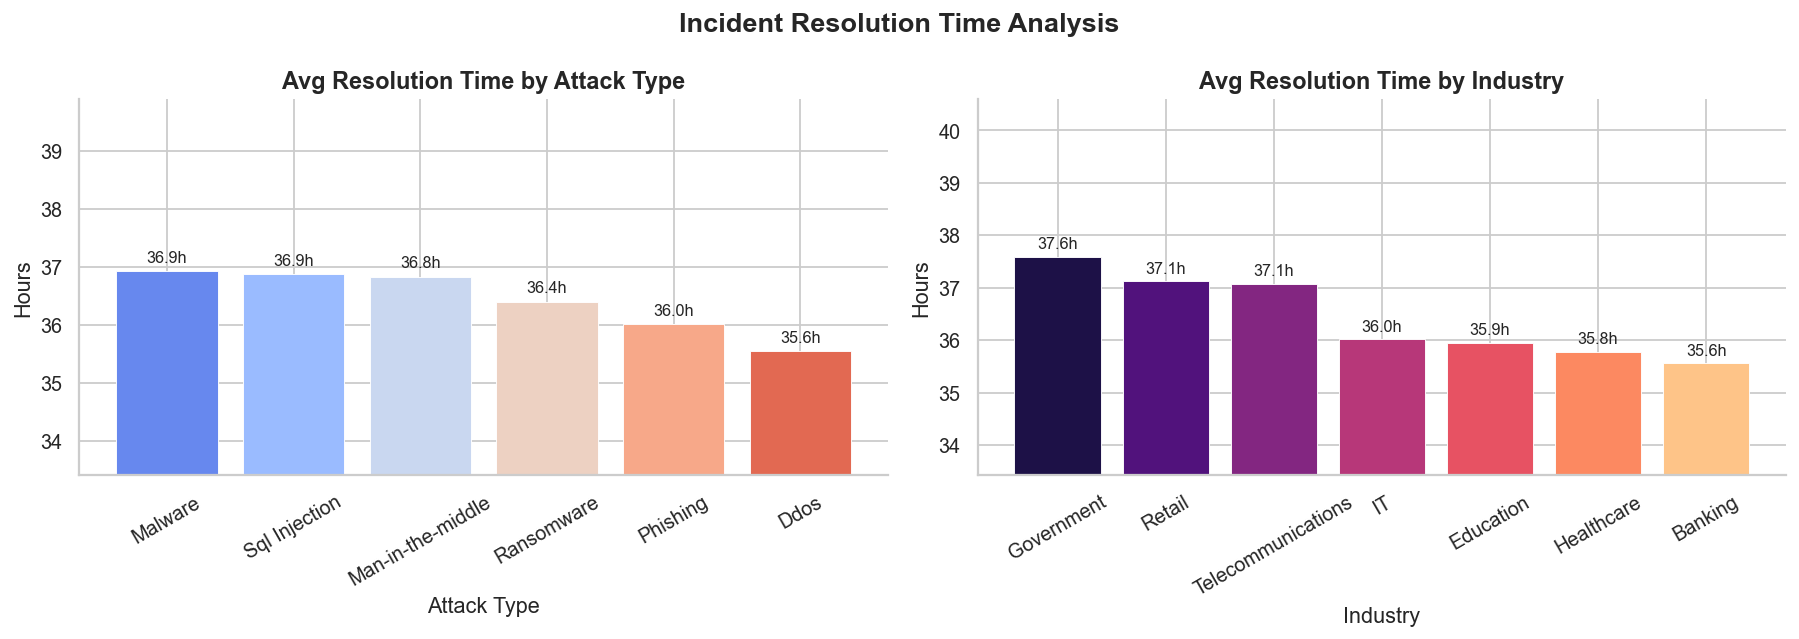

    Saved → plots/08_resolution_time.png
[EDA 9] Defense Effectiveness ...


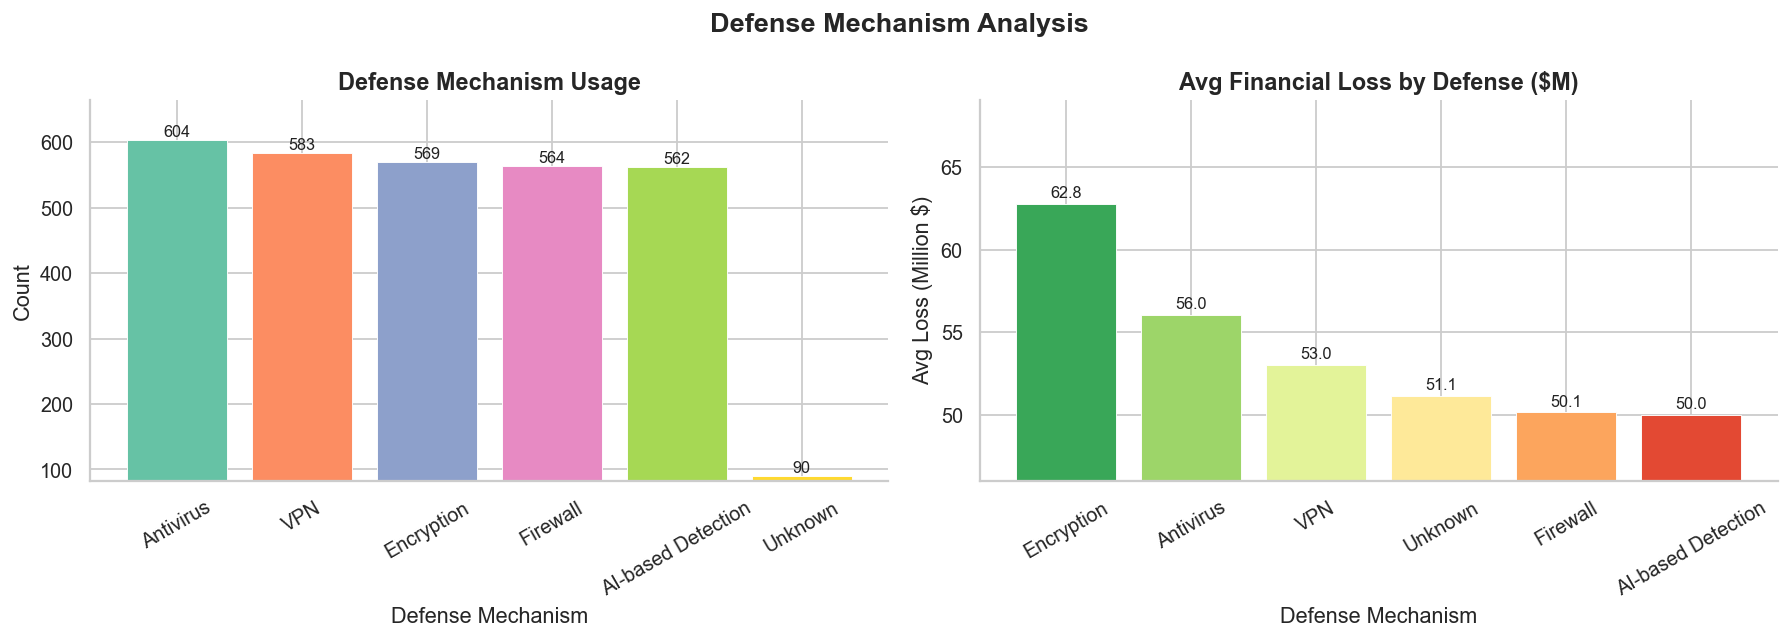

    Saved → plots/09_defense_analysis.png
[EDA 10] Anomaly & Alert Analysis ...


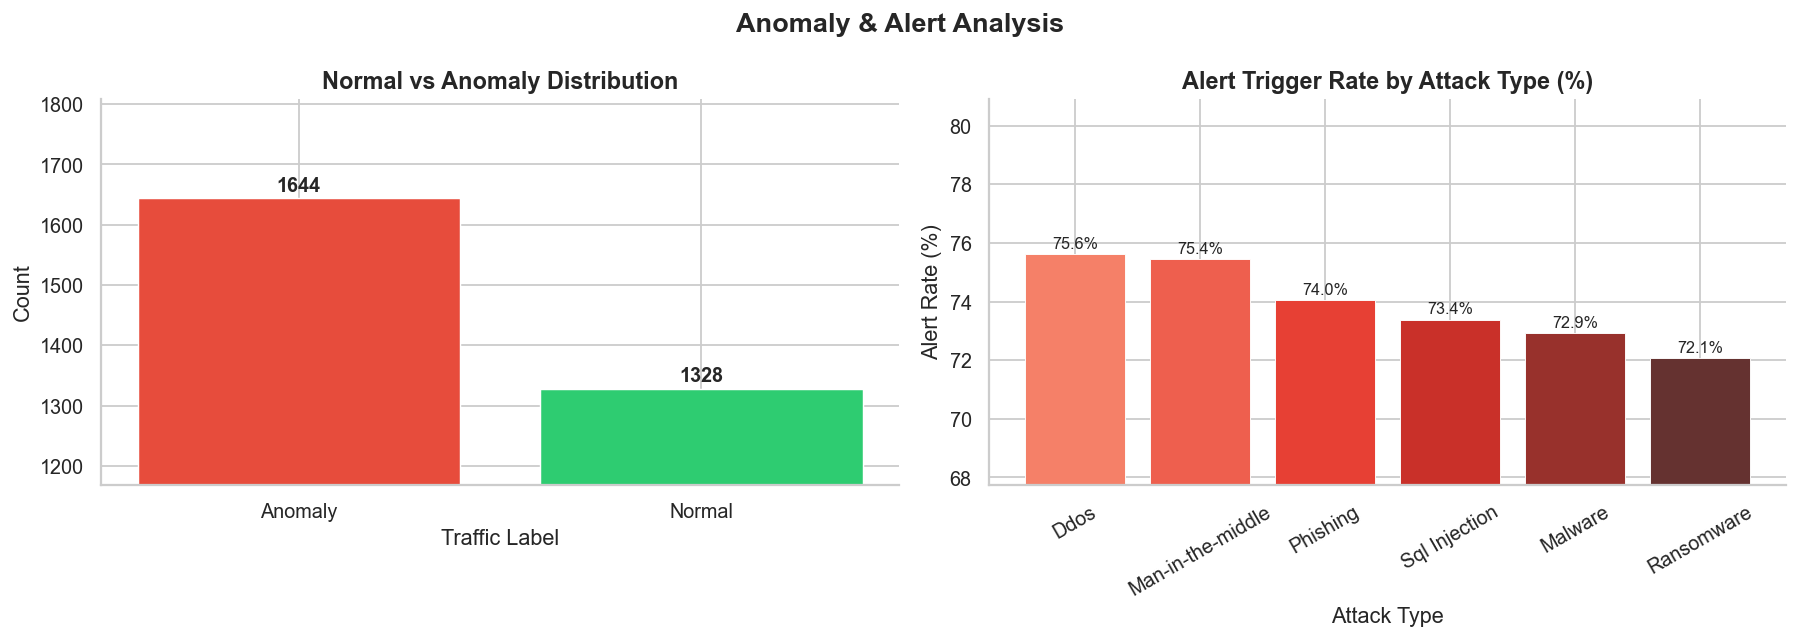

    Saved → plots/10_anomaly_alerts.png
[EDA 11] Correlation Heatmap ...


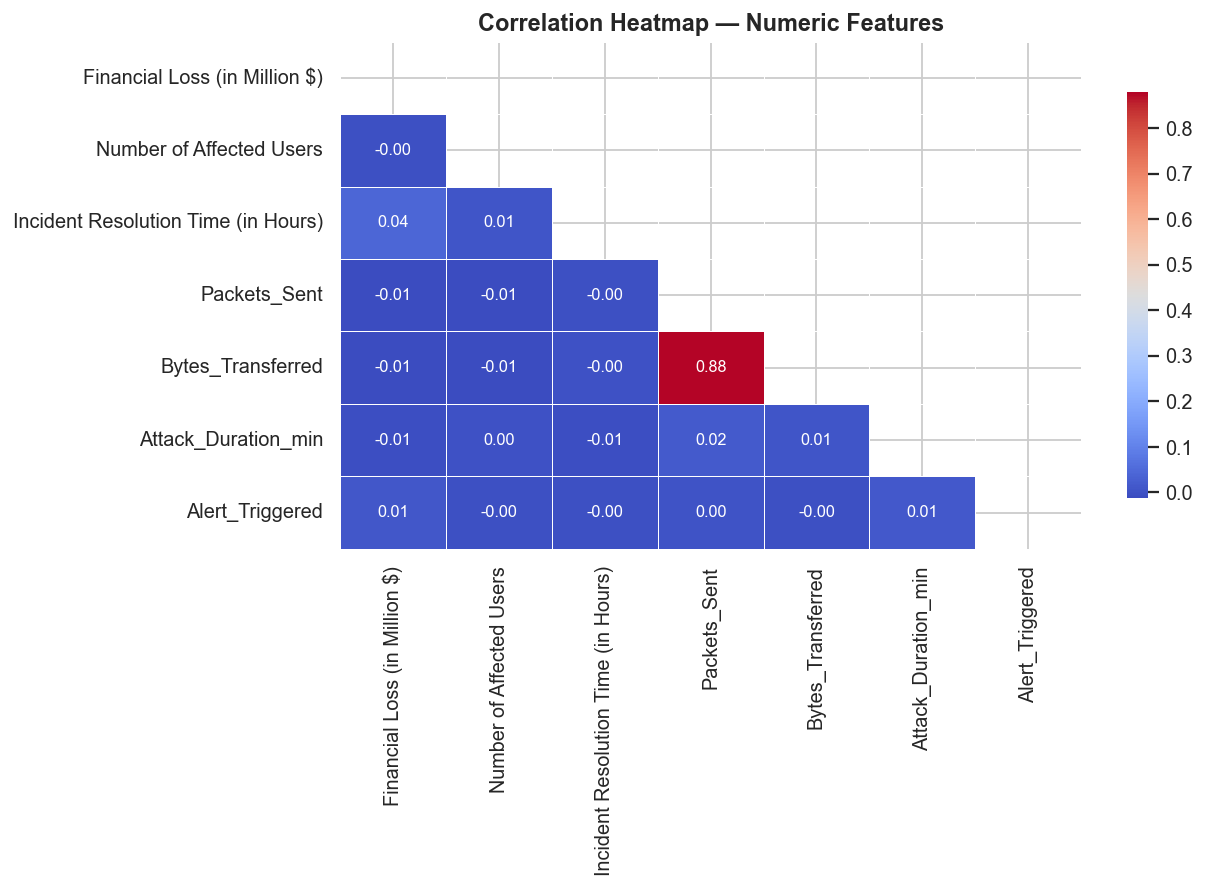

    Saved → plots/11_correlation_heatmap.png

  KEY FINDINGS SUMMARY
  Total Incidents          : 2,972
  Total Financial Loss     : $161,432.4M
  Avg Loss per Incident    : $54.32M
  Most Common Attack       : Ddos
  Most Targeted Industry   : IT
  Most Targeted Port       : 3306
  Top Source Country       : United Kingdom
  Anomaly Rate             : 55.3%
  Alert Trigger Rate       : 73.9%
  Avg Resolution Time      : 36.4 hours

  ML SECTION  (3 models + SHAP)

[ML 1] Preparing ML dataset ...
[ML 2] Engineering features ...
    Classifier features : 18
    Regressor  features : 19

[ML 3] Training Traffic Label Classifier (Random Forest) ...

    ── Classification Report (hold-out) ──
              precision    recall  f1-score   support

     anomaly       0.76      0.83      0.79       329
      normal       0.76      0.67      0.71       266

    accuracy                           0.76       595
   macro avg       0.76      0.75      0.75       595
weighted avg       0.76      0

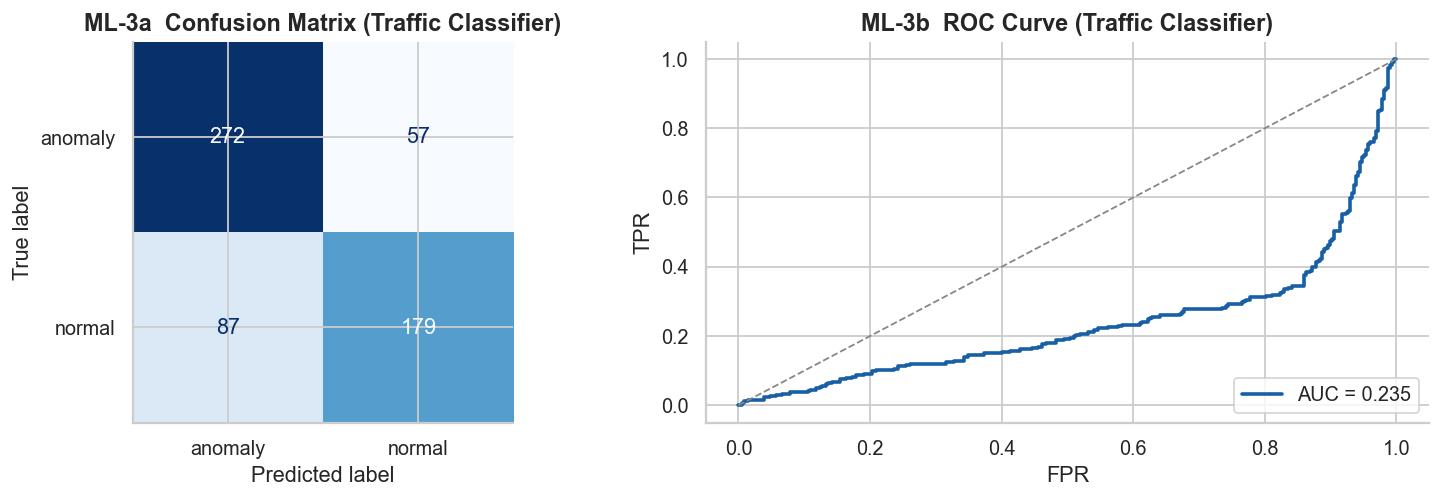

    Saved → plots/ML_03_classifier_eval.png


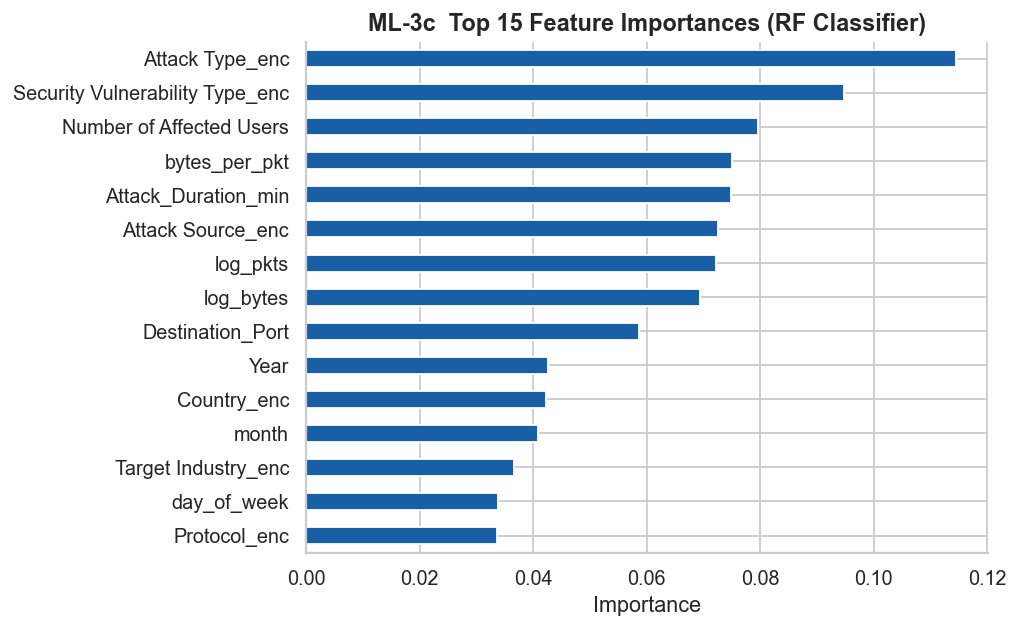

    Saved → plots/ML_03_feature_importance.png

[ML 4] Training Isolation Forest ...
    Flagged     : 446
    Precision   : 0.558  |  Recall: 0.151
    Dual-confirmed : 261


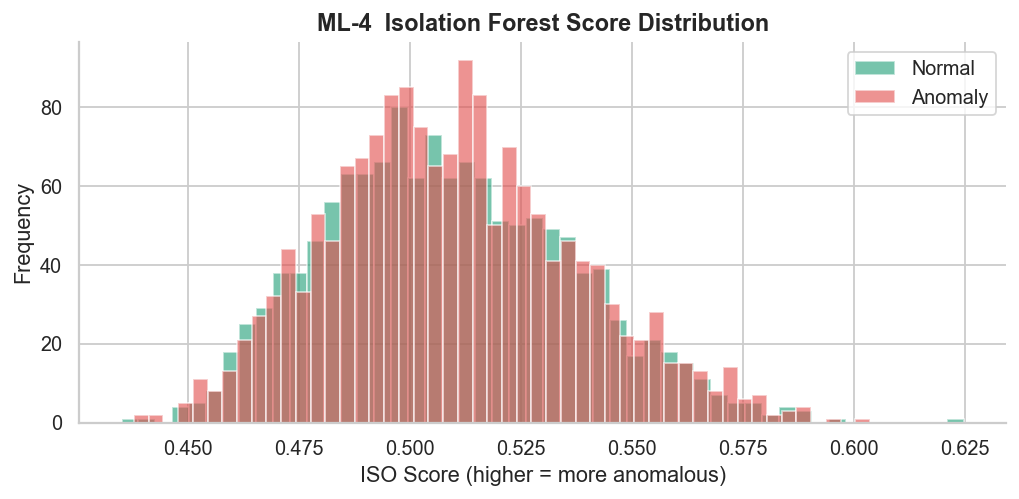

    Saved → plots/ML_04_isolation_forest.png

[ML 5] Computing Risk Score & Tier ...
    High Risk   : 990
    Medium Risk : 992
    Low Risk    : 990


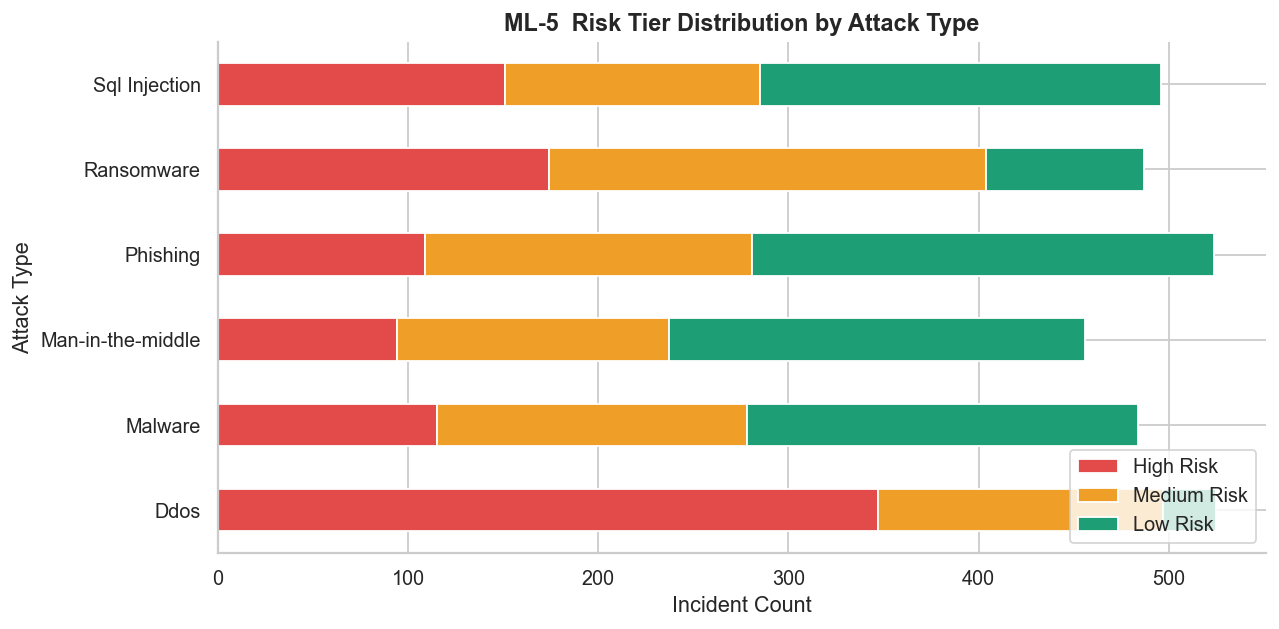

    Saved → plots/ML_05_risk_tier.png

[ML 6] Training Resolution Time Regressor ...
    MAE  : 17.17 hrs  (baseline: 17.26)
    RMSE : 19.93 hrs
    R²   : 0.0066


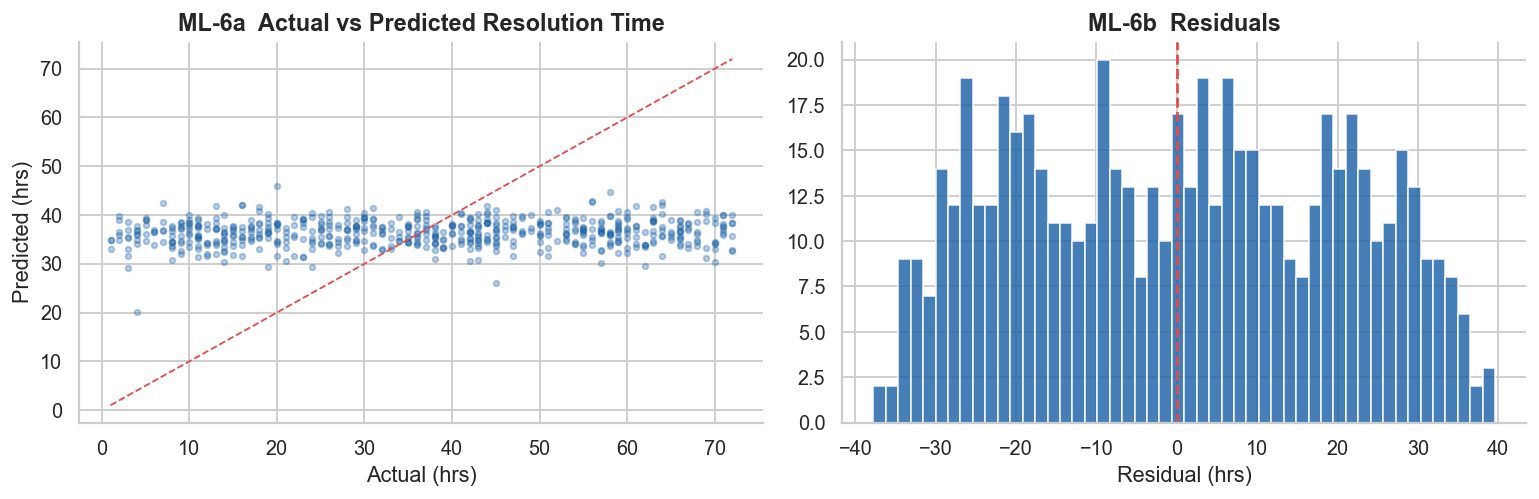

    Saved → plots/ML_06_regressor_eval.png

[ML 7] Training XGBoost Severity Classifier + SHAP ...

    ── XGBoost Severity Report (hold-out) ──
              precision    recall  f1-score   support

    Critical       0.24      0.23      0.24       149
        High       0.22      0.28      0.25       160
         Low       0.24      0.20      0.22       149
      Medium       0.20      0.18      0.19       137

    accuracy                           0.23       595
   macro avg       0.22      0.22      0.22       595
weighted avg       0.23      0.23      0.22       595

    CV F1 macro : 0.2407
    Computing SHAP values (sample of 500 rows) ...


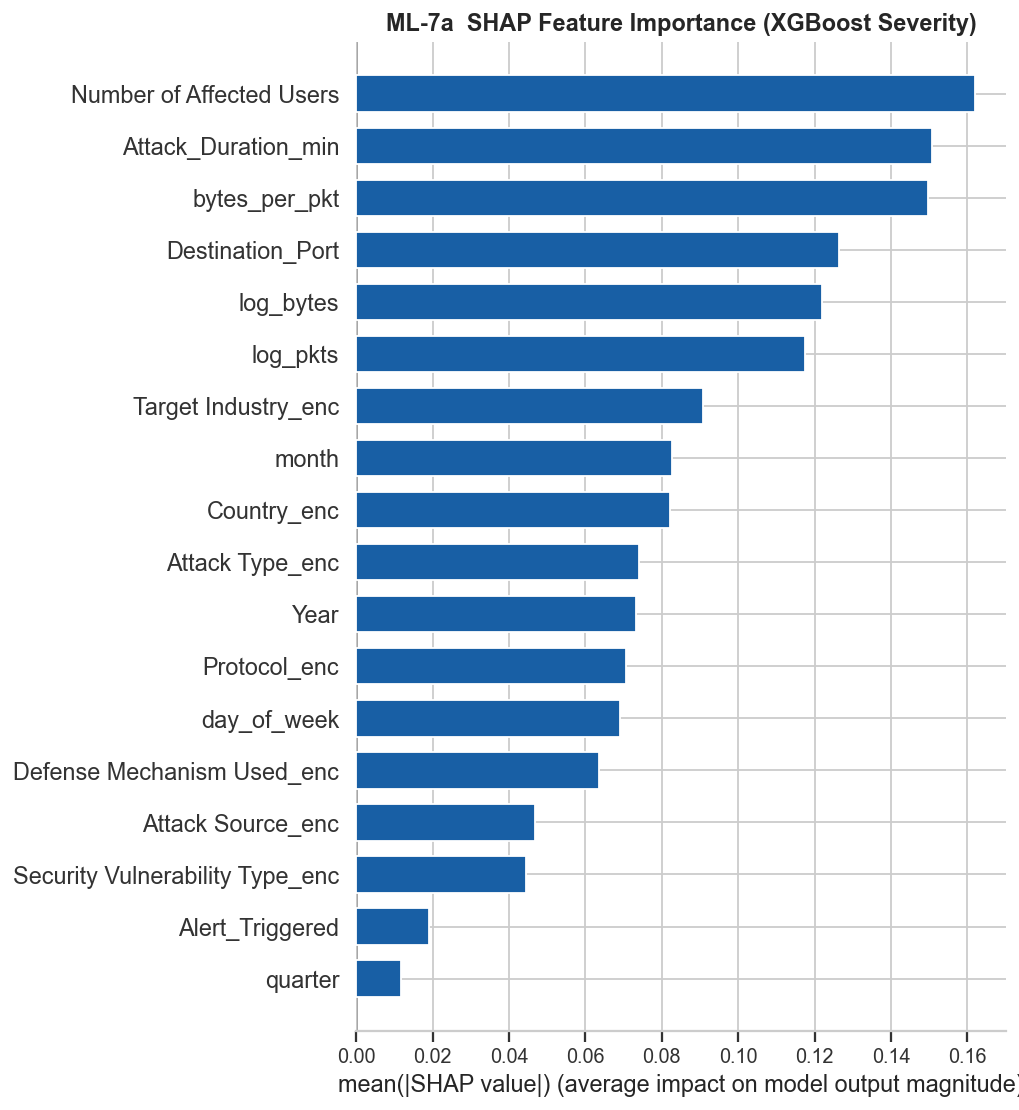

    Saved → plots/ML_07_shap_importance.png


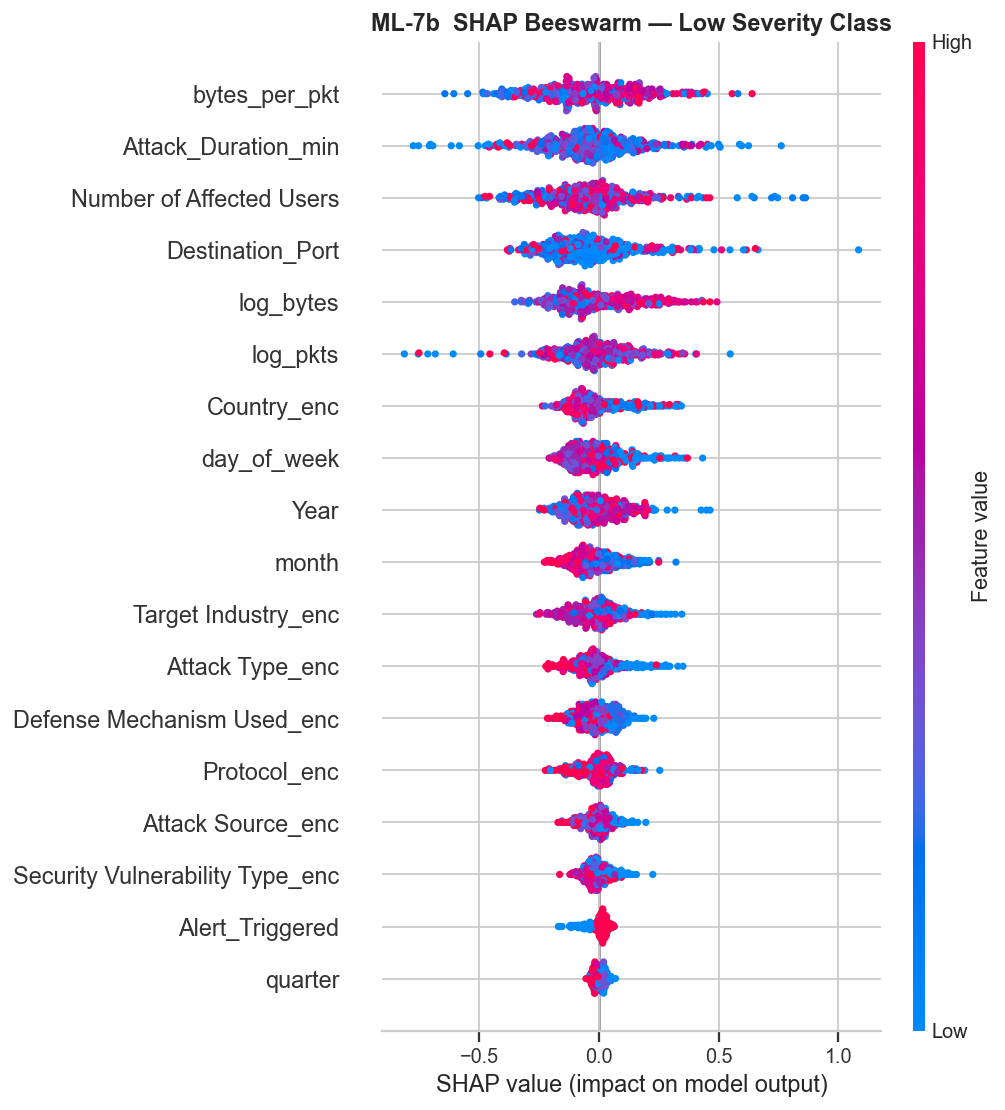

    Saved → plots/ML_07_shap_beeswarm.png

[ML 8] Saving models and output ...
    Saved models → models/
    Saved output → CS_Dataset_ML_Scored.xlsx

  PIPELINE COMPLETE

  EDA charts   : 11
  ML  charts   : 7
  Total charts : 18

  RF Classifier — CV F1: 0.7389  |  AUC: 0.2351
  XGBoost       — CV F1: 0.2407
  Isolation Forest — 446 flagged | 261 dual-confirmed
  Regressor      — MAE: 17.17 hrs  |  R²: 0.0066

  Output : CS_Dataset_ML_Scored.xlsx
  Models : models/
  Plots  : plots/


In [1]:




# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap

from xgboost import XGBClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    IsolationForest,
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay,
)

# ── Global Config ─────────────────────────────────────────────────────────────
INPUT_FILE          = "Complete_CS_DataSet.xlsx"   # ← change path if needed
OUTPUT_FILE         = "CS_Dataset_ML_Scored.xlsx"
MODEL_DIR           = "models"
PLOTS_DIR           = "plots"
RANDOM_STATE        = 42
TEST_SIZE           = 0.20
CV_FOLDS            = 5
ANOMALY_THRESHOLD   = 0.65    # ML_Anomaly_Prob >= this → "Flag"
ISO_CONTAMINATION   = 0.15    # expected anomaly fraction for Isolation Forest

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi":          130,
    "font.family":         "Arial",
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
})

BLUE_PALETTE  = sns.color_palette("Blues_d",  8)
RED_PALETTE   = sns.color_palette("Reds_d",   8)
MULTI_PALETTE = sns.color_palette("tab10",   10)


# ── Shared helpers ────────────────────────────────────────────────────────────
def bar_labels(ax, fmt="{:.0f}", pad=1, fontsize=9, color="#222222", ha="center"):
    for bar in ax.patches:
        h = bar.get_height()
        if h == 0:
            continue
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + pad, fmt.format(h),
                ha=ha, va="bottom", fontsize=fontsize, color=color)

def hbar_labels(ax, fmt="{:.0f}", pad=1, fontsize=9, color="#222222"):
    for bar in ax.patches:
        w = bar.get_width()
        if w == 0:
            continue
        ax.text(w + pad, bar.get_y() + bar.get_height() / 2,
                fmt.format(w), va="center", fontsize=fontsize, color=color)

def save(name):
    path = f"{PLOTS_DIR}/{name}"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"    Saved → {path}")
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING  (shared by EDA and ML sections)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("  LOADING DATA")
print("=" * 70)

df = pd.read_excel(r"D:\bi&sql\Complete CS DataSet.xlsx")

df["Alert_Triggered"] = (
    df["Alert_Triggered"]
    .replace({"Yes": 1, "No": 0})
    .pipe(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)
df["Traffic_Label"] = df["Traffic_Label"].str.strip().str.title()
df["Attack Type"]   = df["Attack Type"].str.strip()
df["Country"]       = df["Country"].str.strip().str.title()

print(f"  Rows     : {len(df):,}")
print(f"  Columns  : {len(df.columns)}")
print(f"  Nulls    : {df.isnull().sum().sum()}")
print(f"  Date range: {df['Incident_Date'].min().date()} → {df['Incident_Date'].max().date()}")
print(f"  Anomaly % : {(df['Traffic_Label']=='Anomaly').mean():.1%}")


# ═══════════════════════════════════════════════════════════════════════════════
#  EDA SECTION
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  EDA SECTION  (11 charts)")
print("=" * 70)


# ── EDA 1: Attack Trends Over Time ────────────────────────────────────────────
print("\n[EDA 1] Attack Trends Over Time ...")

yearly     = df.groupby("Year").size().reset_index(name="Count")
pivot_type = df.groupby(["Year", "Attack Type"]).size().unstack(fill_value=0)
attack_types  = pivot_type.columns.tolist()
colors_trend  = sns.color_palette("tab10", len(attack_types))

fig = plt.figure(figsize=(16, 9), facecolor="#0D1B2A")
ax  = fig.add_subplot(111, facecolor="#0D1B2A")

ax.stackplot(pivot_type.index,
             [pivot_type[col] for col in attack_types],
             labels=attack_types, colors=colors_trend, alpha=0.75)
ax.plot(yearly["Year"], yearly["Count"],
        color="white", linewidth=2.5, linestyle="--",
        marker="o", markersize=7, zorder=5, label="Total")

for _, row in yearly.iterrows():
    ax.annotate(f"{int(row['Count'])}",
                xy=(row["Year"], row["Count"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Cybersecurity Attack Trends 2015–2024",
             fontsize=17, fontweight="bold", color="white", pad=18)
ax.set_xlabel("Year",             fontsize=12, color="#AAAAAA")
ax.set_ylabel("Number of Attacks", fontsize=12, color="#AAAAAA")
ax.set_xlim(yearly["Year"].min() - 0.3, yearly["Year"].max() + 0.3)
ax.set_ylim(0, yearly["Count"].max() * 1.25)
ax.tick_params(colors="#AAAAAA", labelsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
ax.grid(axis="y", color="#FFFFFF", alpha=0.08, linewidth=0.7)
ax.grid(axis="x", visible=False)
legend = ax.legend(loc="upper left", framealpha=0.2, labelcolor="white",
                   fontsize=9, title="Attack Type", title_fontsize=10)
legend.get_title().set_color("white")
plt.tight_layout()
save("01_attack_trends.png")


# ── EDA 2: Attack Type Distribution ──────────────────────────────────────────
print("[EDA 2] Attack Type Distribution ...")

attack_counts = df["Attack Type"].value_counts()
y_min = attack_counts.min() * 0.92
y_max = attack_counts.max() * 1.10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Attack Type Distribution", fontsize=15, fontweight="bold")

axes[0].bar(attack_counts.index, attack_counts.values,
            color=sns.color_palette("deep", len(attack_counts)),
            edgecolor="white", linewidth=0.6)
axes[0].set_title("Attack Frequency by Type")
axes[0].set_xlabel("Attack Type"); axes[0].set_ylabel("Count")
axes[0].set_ylim(y_min, y_max)
axes[0].tick_params(axis="x", rotation=30)
bar_labels(axes[0], pad=1)

wedge_colors = sns.color_palette("deep", len(attack_counts))
wedges, texts, autotexts = axes[1].pie(
    attack_counts.values, labels=None, autopct="%1.1f%%",
    startangle=140, colors=wedge_colors, pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=1.2))
for at in autotexts:
    at.set_fontsize(8); at.set_color("white"); at.set_fontweight("bold")
axes[1].legend(wedges, attack_counts.index, title="Attack Type",
               loc="lower center", bbox_to_anchor=(0.5, -0.12),
               ncol=3, fontsize=8)
axes[1].set_title("Attack Type Share (%)")
plt.tight_layout()
save("02_attack_distribution.png")


# ── EDA 3: Geographic Analysis ────────────────────────────────────────────────
print("[EDA 3] Geographic Analysis ...")

country_attacks = df["Country"].value_counts()
country_loss    = df.groupby("Country")["Financial Loss (in Million $)"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Geographic Threat Analysis", fontsize=15, fontweight="bold")

ca_min = country_attacks.min() * 0.90
ca_max = country_attacks.max() * 1.10
axes[0].barh(country_attacks.index, country_attacks.values,
             color=sns.color_palette("Blues_d", len(country_attacks)),
             edgecolor="white", linewidth=0.5)
axes[0].set_title("Attacks by Source Country"); axes[0].set_xlabel("Number of Attacks")
axes[0].set_xlim(ca_min, ca_max)
for i, v in enumerate(country_attacks.values):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

cl_min = country_loss.min() * 0.90
cl_max = country_loss.max() * 1.10
axes[1].barh(country_loss.index, country_loss.values,
             color=sns.color_palette("Reds_d", len(country_loss)),
             edgecolor="white", linewidth=0.5)
axes[1].set_title("Total Financial Loss by Country ($M)")
axes[1].set_xlabel("Financial Loss (Million $)")
axes[1].set_xlim(cl_min, cl_max)
for i, v in enumerate(country_loss.values):
    axes[1].text(v + 10, i, f"${v:,.0f}M", va="center", fontsize=8)
plt.tight_layout()
save("03_geographic_analysis.png")


# ── EDA 4: Top 10 Source IPs ─────────────────────────────────────────────────
print("[EDA 4] Top 10 Source IPs ...")

top_ips = df["Source_IP"].value_counts().head(10)
x_min   = top_ips.min() * 0.88
x_max   = top_ips.max() * 1.12

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_ips.index[::-1], top_ips.values[::-1],
               color=sns.color_palette("OrRd_d", 10),
               edgecolor="white", linewidth=0.5)
ax.set_title("Top 10 Attacker Source IPs", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Attacks"); ax.set_xlim(x_min, x_max)
for bar in bars:
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va="center", fontsize=9)
plt.tight_layout()
save("04_top_source_ips.png")


# ── EDA 5: Targeted Ports & Protocols ────────────────────────────────────────
print("[EDA 5] Targeted Ports & Protocols ...")

top_ports    = df["Destination_Port"].value_counts().head(10)
proto_counts = df["Protocol"].value_counts()
port_ymin = top_ports.min() * 0.90; port_ymax = top_ports.max() * 1.12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Network Targeting Analysis", fontsize=15, fontweight="bold")

axes[0].bar(top_ports.index.astype(str), top_ports.values,
            color=sns.color_palette("viridis", 10), edgecolor="white", linewidth=0.5)
axes[0].set_title("Top 10 Targeted Ports"); axes[0].set_xlabel("Port Number")
axes[0].set_ylabel("Attack Count"); axes[0].set_ylim(port_ymin, port_ymax)
axes[0].tick_params(axis="x", rotation=45)
bar_labels(axes[0], pad=1)

proto_sorted = proto_counts.sort_values()
proto_colors = sns.color_palette("Set2", len(proto_sorted))
bars_proto   = axes[1].barh(proto_sorted.index, proto_sorted.values,
                             color=proto_colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("Protocol Distribution"); axes[1].set_xlabel("Number of Attacks")
for i, (bar, val) in enumerate(zip(bars_proto, proto_sorted.values)):
    pct = (val / proto_counts.sum()) * 100
    axes[1].text(val + 2, i, f"{val:,} ({pct:.1f}%)",
                 va="center", fontsize=8, fontweight="bold")
plt.tight_layout()
save("05_ports_protocols.png")


# ── EDA 6: Industry Targeting ─────────────────────────────────────────────────
print("[EDA 6] Industry Targeting ...")

industry_attacks = df["Target Industry"].value_counts()
industry_loss    = df.groupby("Target Industry")["Financial Loss (in Million $)"].mean().sort_values(ascending=False)

ia_ymin = industry_attacks.min() * 0.92; ia_ymax = industry_attacks.max() * 1.10
il_ymin = industry_loss.min()    * 0.92; il_ymax = industry_loss.max()    * 1.10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Industry Targeting Analysis", fontsize=15, fontweight="bold")

axes[0].bar(industry_attacks.index, industry_attacks.values,
            color=sns.color_palette("tab10", len(industry_attacks)),
            edgecolor="white", linewidth=0.5)
axes[0].set_title("Attacks by Industry"); axes[0].set_xlabel("Industry")
axes[0].set_ylabel("Count"); axes[0].set_ylim(ia_ymin, ia_ymax)
axes[0].tick_params(axis="x", rotation=30); bar_labels(axes[0], pad=1)

axes[1].bar(industry_loss.index, industry_loss.values,
            color=sns.color_palette("tab10", len(industry_loss)),
            edgecolor="white", linewidth=0.5)
axes[1].set_title("Avg Financial Loss by Industry ($M)")
axes[1].set_xlabel("Industry"); axes[1].set_ylabel("Avg Loss (Million $)")
axes[1].set_ylim(il_ymin, il_ymax)
axes[1].tick_params(axis="x", rotation=30)
bar_labels(axes[1], fmt="{:.1f}", pad=0.2)
plt.tight_layout()
save("06_industry_analysis.png")


# ── EDA 7: Financial Impact ───────────────────────────────────────────────────
print("[EDA 7] Financial Impact Analysis ...")

p99    = df["Financial Loss (in Million $)"].quantile(0.99)
df_cap = df[df["Financial Loss (in Million $)"] <= p99].copy()
labels_bp  = df_cap["Attack Type"].unique().tolist()
groups     = [df_cap[df_cap["Attack Type"] == t]["Financial Loss (in Million $)"].dropna()
              for t in labels_bp]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Financial Impact Analysis", fontsize=15, fontweight="bold")
bp = ax.boxplot(groups, labels=labels_bp, patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], sns.color_palette("deep", len(labels_bp))):
    patch.set_facecolor(color)
ax.set_title("Financial Loss by Attack Type (capped at 99th pct)")
ax.set_xlabel("Attack Type"); ax.set_ylabel("Financial Loss ($M)")
ax.set_ylim(0, p99 * 1.05); ax.tick_params(axis="x", rotation=30)
for i, (mline, lbl) in enumerate(zip(bp["medians"], labels_bp)):
    mv = mline.get_ydata()[0]
    ax.text(i + 1, mv + 0.5, f"${mv:.1f}M", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
save("07_financial_impact.png")


# ── EDA 8: Resolution Time ────────────────────────────────────────────────────
print("[EDA 8] Resolution Time Analysis ...")

res_time     = df.groupby("Attack Type")["Incident Resolution Time (in Hours)"].mean().sort_values(ascending=False)
res_industry = df.groupby("Target Industry")["Incident Resolution Time (in Hours)"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Incident Resolution Time Analysis", fontsize=15, fontweight="bold")

axes[0].bar(res_time.index, res_time.values,
            color=sns.color_palette("coolwarm", len(res_time)),
            edgecolor="white", linewidth=0.5)
axes[0].set_ylim(res_time.min() * 0.94, res_time.max() * 1.08)
axes[0].set_title("Avg Resolution Time by Attack Type")
axes[0].set_xlabel("Attack Type"); axes[0].set_ylabel("Hours")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(res_time.values):
    axes[0].text(i, v + 0.1, f"{v:.1f}h", ha="center", va="bottom", fontsize=9)

axes[1].bar(res_industry.index, res_industry.values,
            color=sns.color_palette("magma", len(res_industry)),
            edgecolor="white", linewidth=0.5)
axes[1].set_ylim(res_industry.min() * 0.94, res_industry.max() * 1.08)
axes[1].set_title("Avg Resolution Time by Industry")
axes[1].set_xlabel("Industry"); axes[1].set_ylabel("Hours")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(res_industry.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}h", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save("08_resolution_time.png")


# ── EDA 9: Defense Effectiveness ─────────────────────────────────────────────
print("[EDA 9] Defense Effectiveness ...")

defense_counts = df["Defense Mechanism Used"].value_counts()
defense_loss   = df.groupby("Defense Mechanism Used")["Financial Loss (in Million $)"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Defense Mechanism Analysis", fontsize=15, fontweight="bold")

axes[0].bar(defense_counts.index, defense_counts.values,
            color=sns.color_palette("Set2", len(defense_counts)),
            edgecolor="white", linewidth=0.5)
axes[0].set_ylim(defense_counts.min() * 0.92, defense_counts.max() * 1.10)
axes[0].set_title("Defense Mechanism Usage")
axes[0].set_xlabel("Defense Mechanism"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30); bar_labels(axes[0], pad=1)

axes[1].bar(defense_loss.index, defense_loss.values,
            color=sns.color_palette("RdYlGn_r", len(defense_loss)),
            edgecolor="white", linewidth=0.5)
axes[1].set_ylim(defense_loss.min() * 0.92, defense_loss.max() * 1.10)
axes[1].set_title("Avg Financial Loss by Defense ($M)")
axes[1].set_xlabel("Defense Mechanism"); axes[1].set_ylabel("Avg Loss (Million $)")
axes[1].tick_params(axis="x", rotation=30)
bar_labels(axes[1], fmt="{:.1f}", pad=0.2)
plt.tight_layout()
save("09_defense_analysis.png")


# ── EDA 10: Anomaly & Alert Analysis ─────────────────────────────────────────
print("[EDA 10] Anomaly & Alert Analysis ...")

label_counts = df["Traffic_Label"].value_counts()
alert_rate   = df.groupby("Attack Type")["Alert_Triggered"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anomaly & Alert Analysis", fontsize=15, fontweight="bold")

colors_label = ["#E74C3C" if x == "Anomaly" else "#2ECC71" for x in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values,
            color=colors_label, edgecolor="white", linewidth=0.8)
axes[0].set_ylim(label_counts.min() * 0.88, label_counts.max() * 1.10)
axes[0].set_title("Normal vs Anomaly Distribution")
axes[0].set_xlabel("Traffic Label"); axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[1].bar(alert_rate.index, alert_rate.values * 100,
            color=sns.color_palette("Reds_d", len(alert_rate)),
            edgecolor="white", linewidth=0.5)
axes[1].set_ylim(alert_rate.min() * 100 * 0.94, alert_rate.max() * 100 * 1.07)
axes[1].set_title("Alert Trigger Rate by Attack Type (%)")
axes[1].set_xlabel("Attack Type"); axes[1].set_ylabel("Alert Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(alert_rate.values):
    axes[1].text(i, v * 100 + 0.1, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save("10_anomaly_alerts.png")


# ── EDA 11: Correlation Heatmap ───────────────────────────────────────────────
print("[EDA 11] Correlation Heatmap ...")

numeric_cols = [
    "Financial Loss (in Million $)", "Number of Affected Users",
    "Incident Resolution Time (in Hours)", "Packets_Sent",
    "Bytes_Transferred", "Attack_Duration_min", "Alert_Triggered",
]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save("11_correlation_heatmap.png")


# ── EDA Summary ───────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"  Total Incidents          : {len(df):,}")
print(f"  Total Financial Loss     : ${df['Financial Loss (in Million $)'].sum():,.1f}M")
print(f"  Avg Loss per Incident    : ${df['Financial Loss (in Million $)'].mean():,.2f}M")
print(f"  Most Common Attack       : {df['Attack Type'].value_counts().index[0]}")
print(f"  Most Targeted Industry   : {df['Target Industry'].value_counts().index[0]}")
print(f"  Most Targeted Port       : {df['Destination_Port'].value_counts().index[0]}")
print(f"  Top Source Country       : {df['Country'].value_counts().index[0]}")
print(f"  Anomaly Rate             : {(df['Traffic_Label']=='Anomaly').mean()*100:.1f}%")
print(f"  Alert Trigger Rate       : {df['Alert_Triggered'].mean()*100:.1f}%")
print(f"  Avg Resolution Time      : {df['Incident Resolution Time (in Hours)'].mean():.1f} hours")
print("=" * 55)


# ═══════════════════════════════════════════════════════════════════════════════
#  ML SECTION
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  ML SECTION  (3 models + SHAP)")
print("=" * 70)


# ── ML 1: Prepare ML copy ─────────────────────────────────────────────────────
print("\n[ML 1] Preparing ML dataset ...")

ml = df.copy()
ml["Traffic_Label_lower"] = ml["Traffic_Label"].str.lower()   # keep lowercase for ML

# ── ML 2: Feature Engineering ────────────────────────────────────────────────
print("[ML 2] Engineering features ...")

ml["month"]         = pd.to_datetime(ml["Incident_Date"]).dt.month
ml["day_of_week"]   = pd.to_datetime(ml["Incident_Date"]).dt.dayofweek
ml["quarter"]       = pd.to_datetime(ml["Incident_Date"]).dt.quarter
ml["bytes_per_pkt"] = ml["Bytes_Transferred"]    / (ml["Packets_Sent"]           + 1)
ml["loss_per_user"] = ml["Financial Loss (in Million $)"] / (ml["Number of Affected Users"] + 1)
ml["log_bytes"]     = np.log1p(ml["Bytes_Transferred"])
ml["log_pkts"]      = np.log1p(ml["Packets_Sent"])

CATEGORICAL_COLS = [
    "Country", "Protocol", "Attack Type", "Attack Source",
    "Target Industry", "Security Vulnerability Type", "Defense Mechanism Used",
]
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    ml[col + "_enc"] = le.fit_transform(ml[col])
    encoders[col]    = le

FEATURES_CLF = (
    [c + "_enc" for c in CATEGORICAL_COLS]
    + ["log_pkts", "log_bytes", "Attack_Duration_min",
       "Number of Affected Users", "Alert_Triggered",
       "month", "day_of_week", "quarter", "Destination_Port",
       "bytes_per_pkt", "Year"]
)
FEATURES_REG = FEATURES_CLF + ["Financial Loss (in Million $)"]

print(f"    Classifier features : {len(FEATURES_CLF)}")
print(f"    Regressor  features : {len(FEATURES_REG)}")


# ── ML 3: Traffic Label Classifier (Random Forest) ───────────────────────────
print("\n[ML 3] Training Traffic Label Classifier (Random Forest) ...")

le_label = LabelEncoder()
y_clf    = le_label.fit_transform(ml["Traffic_Label_lower"])
X_clf    = ml[FEATURES_CLF].fillna(0)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=TEST_SIZE, stratify=y_clf, random_state=RANDOM_STATE)

clf_rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE)
clf_rf.fit(X_tr, y_tr)

y_pred_clf = clf_rf.predict(X_te)
anomaly_idx = list(le_label.classes_).index("anomaly")
y_prob_clf  = clf_rf.predict_proba(X_te)[:, anomaly_idx]
auc_rf      = roc_auc_score(y_te, y_prob_clf)
cv_f1_rf    = cross_val_score(
    clf_rf, X_clf, y_clf,
    cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1).mean()

print("\n    ── Classification Report (hold-out) ──")
print(classification_report(y_te, y_pred_clf, target_names=le_label.classes_))
print(f"    AUC-ROC      : {auc_rf:.4f}")
print(f"    CV F1 macro  : {cv_f1_rf:.4f}")

ml["ML_Traffic_Pred"]            = le_label.inverse_transform(clf_rf.predict(X_clf))
ml["ML_Anomaly_Prob"]            = clf_rf.predict_proba(X_clf)[:, anomaly_idx].round(4)
ml["ML_Traffic_Correct"]         = (ml["ML_Traffic_Pred"] == ml["Traffic_Label_lower"]).astype(int)
ml["ML_High_Confidence_Anomaly"] = np.where(ml["ML_Anomaly_Prob"] >= ANOMALY_THRESHOLD, "Flag", "OK")

# ── Plot ML-3a: Confusion matrix + ROC ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_clf),
                       display_labels=le_label.classes_).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("ML-3a  Confusion Matrix (Traffic Classifier)")

fpr, tpr, _ = roc_curve(y_te, y_prob_clf)
axes[1].plot(fpr, tpr, lw=2, color="#185FA5", label=f"AUC = {auc_rf:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="#888780", lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ML-3b  ROC Curve (Traffic Classifier)")
axes[1].legend(loc="lower right")
plt.tight_layout()
save("ML_03_classifier_eval.png")

# ── Plot ML-3b: Feature importance ───────────────────────────────────────────
fi_rf = pd.Series(clf_rf.feature_importances_, index=FEATURES_CLF).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
fi_rf.plot(kind="barh", ax=ax, color="#185FA5")
ax.set_title("ML-3c  Top 15 Feature Importances (RF Classifier)")
ax.set_xlabel("Importance")
plt.tight_layout()
save("ML_03_feature_importance.png")


# ── ML 4: Isolation Forest ────────────────────────────────────────────────────
print("\n[ML 4] Training Isolation Forest ...")

iso = IsolationForest(
    n_estimators=300, contamination=ISO_CONTAMINATION,
    random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_clf)

ml["ISO_Score"] = (-iso.score_samples(X_clf)).round(4)
ml["ISO_Flag"]  = (iso.predict(X_clf) == -1).astype(int)

iso_precision = (ml[ml["ISO_Flag"]==1]["Traffic_Label_lower"] == "anomaly").mean()
iso_recall    = ml[ml["Traffic_Label_lower"]=="anomaly"]["ISO_Flag"].mean()
ml["Dual_Confirmed_Anomaly"] = (
    (ml["ML_Traffic_Pred"] == "anomaly") & (ml["ISO_Flag"] == 1)).astype(int)

print(f"    Flagged     : {ml['ISO_Flag'].sum():,}")
print(f"    Precision   : {iso_precision:.3f}  |  Recall: {iso_recall:.3f}")
print(f"    Dual-confirmed : {ml['Dual_Confirmed_Anomaly'].sum():,}")

# ── Plot ML-4: ISO score distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ml[ml["Traffic_Label_lower"]=="normal"]["ISO_Score"].plot(
    kind="hist", bins=50, alpha=0.6, ax=ax, label="Normal", color="#1D9E75")
ml[ml["Traffic_Label_lower"]=="anomaly"]["ISO_Score"].plot(
    kind="hist", bins=50, alpha=0.6, ax=ax, label="Anomaly", color="#E24B4A")
ax.set_xlabel("ISO Score (higher = more anomalous)")
ax.set_title("ML-4  Isolation Forest Score Distribution")
ax.legend()
plt.tight_layout()
save("ML_04_isolation_forest.png")


# ── ML 5: Composite Risk Score & Tier ────────────────────────────────────────
print("\n[ML 5] Computing Risk Score & Tier ...")

iso_min, iso_max  = ml["ISO_Score"].min(), ml["ISO_Score"].max()
loss_min, loss_max = ml["Financial Loss (in Million $)"].min(), ml["Financial Loss (in Million $)"].max()

ml["ISO_Score_norm"] = (ml["ISO_Score"] - iso_min) / (iso_max - iso_min)
ml["Loss_norm"]      = (ml["Financial Loss (in Million $)"] - loss_min) / (loss_max - loss_min)

ml["Risk_Score"] = (
    0.50 * ml["ML_Anomaly_Prob"]  +
    0.30 * ml["ISO_Score_norm"]   +
    0.20 * ml["Loss_norm"]
).round(4)

t33 = ml["Risk_Score"].quantile(0.333)
t67 = ml["Risk_Score"].quantile(0.667)
ml["Risk_Tier"] = pd.cut(
    ml["Risk_Score"],
    bins=[-np.inf, t33, t67, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"])
ml["Risk_Tier_Sort"] = ml["Risk_Tier"].map({"High Risk": 1, "Medium Risk": 2, "Low Risk": 3})

print(f"    High Risk   : {(ml['Risk_Tier']=='High Risk').sum():,}")
print(f"    Medium Risk : {(ml['Risk_Tier']=='Medium Risk').sum():,}")
print(f"    Low Risk    : {(ml['Risk_Tier']=='Low Risk').sum():,}")

# ── Plot ML-5: Risk tier stacked bar by attack type ──────────────────────────
ct = pd.crosstab(ml["Attack Type"], ml["Risk_Tier"])[["High Risk", "Medium Risk", "Low Risk"]]
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind="barh", stacked=True, ax=ax,
        color={"High Risk": "#E24B4A", "Medium Risk": "#EF9F27", "Low Risk": "#1D9E75"})
ax.set_title("ML-5  Risk Tier Distribution by Attack Type")
ax.set_xlabel("Incident Count"); ax.legend(loc="lower right")
plt.tight_layout()
save("ML_05_risk_tier.png")


# ── ML 6: Resolution Time Regressor ──────────────────────────────────────────
print("\n[ML 6] Training Resolution Time Regressor ...")

X_reg = ml[FEATURES_REG].fillna(0)
y_reg = ml["Incident Resolution Time (in Hours)"]

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)

reg = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE)
reg.fit(X_tr_r, y_tr_r)

y_pred_r  = reg.predict(X_te_r)
mae_m     = mean_absolute_error(y_te_r, y_pred_r)
rmse_m    = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
r2_m      = r2_score(y_te_r, y_pred_r)
mae_base  = mean_absolute_error(y_te_r, [y_reg.mean()] * len(y_te_r))

print(f"    MAE  : {mae_m:.2f} hrs  (baseline: {mae_base:.2f})")
print(f"    RMSE : {rmse_m:.2f} hrs")
print(f"    R²   : {r2_m:.4f}")

ml["ML_Predicted_Resolution_Hrs"] = reg.predict(X_reg).round(1)

# ── Plot ML-6: Actual vs predicted ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_te_r, y_pred_r, alpha=0.3, s=10, color="#185FA5")
lims = [y_reg.min(), y_reg.max()]
axes[0].plot(lims, lims, "--", color="#E24B4A", lw=1)
axes[0].set_xlabel("Actual (hrs)"); axes[0].set_ylabel("Predicted (hrs)")
axes[0].set_title("ML-6a  Actual vs Predicted Resolution Time")

residuals = y_te_r.values - y_pred_r
axes[1].hist(residuals, bins=50, color="#185FA5", alpha=0.8)
axes[1].axvline(0, color="#E24B4A", lw=1.5, linestyle="--")
axes[1].set_xlabel("Residual (hrs)"); axes[1].set_title("ML-6b  Residuals")
plt.tight_layout()
save("ML_06_regressor_eval.png")


# ── ML 7: XGBoost Severity Classifier + SHAP ─────────────────────────────────
print("\n[ML 7] Training XGBoost Severity Classifier + SHAP ...")

# Derive severity label from financial loss quartiles
bins_sev   = [0, 26.66, 50.41, 74.11, ml["Financial Loss (in Million $)"].max() + 1]
labels_sev = ["Low", "Medium", "High", "Critical"]
ml["Severity"] = pd.cut(ml["Financial Loss (in Million $)"],
                        bins=bins_sev, labels=labels_sev)

le_sev = LabelEncoder()
y_sev  = le_sev.fit_transform(ml["Severity"])
X_sev  = ml[FEATURES_CLF].fillna(0)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_sev, y_sev, test_size=TEST_SIZE, stratify=y_sev, random_state=RANDOM_STATE)

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_tr_s, y_tr_s,
        eval_set=[(X_te_s, y_te_s)], verbose=False)

y_pred_s = xgb.predict(X_te_s)
cv_f1_xgb = cross_val_score(
    xgb, X_sev, y_sev,
    cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1).mean()

print("\n    ── XGBoost Severity Report (hold-out) ──")
print(classification_report(y_te_s, y_pred_s, target_names=le_sev.classes_))
print(f"    CV F1 macro : {cv_f1_xgb:.4f}")

ml["XGB_Severity_Pred"] = le_sev.inverse_transform(xgb.predict(X_sev))

# ── SHAP values ───────────────────────────────────────────────────────────────
print("    Computing SHAP values (sample of 500 rows) ...")
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_sev), 500, replace=False)
X_shap     = X_sev.iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)   # shape: (n_samples, n_features, n_classes) or list

# Flatten for summary plot — mean absolute across all classes
if isinstance(shap_values, list):
    shap_mean = np.abs(np.stack(shap_values, axis=2)).mean(axis=2)
else:
    shap_mean = np.abs(shap_values).mean(axis=2) if shap_values.ndim == 3 else np.abs(shap_values)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_mean, X_shap, feature_names=FEATURES_CLF,
                  plot_type="bar", show=False, color="#185FA5")
ax = plt.gca()
ax.set_title("ML-7a  SHAP Feature Importance (XGBoost Severity)", fontweight="bold")
plt.tight_layout()
save("ML_07_shap_importance.png")

# SHAP beeswarm for first class (Low severity)
fig, ax = plt.subplots(figsize=(9, 6))
sv_class0 = shap_values[0] if isinstance(shap_values, list) else shap_values[:, :, 0]
shap.summary_plot(sv_class0, X_shap, feature_names=FEATURES_CLF, show=False)
ax = plt.gca()
ax.set_title("ML-7b  SHAP Beeswarm — Low Severity Class", fontweight="bold")
plt.tight_layout()
save("ML_07_shap_beeswarm.png")


# ── ML 8: Save models + scored Excel ─────────────────────────────────────────
print("\n[ML 8] Saving models and output ...")

joblib.dump({"model": clf_rf, "encoders": encoders, "label_encoder": le_label,
             "features": FEATURES_CLF},
            f"{MODEL_DIR}/traffic_classifier.pkl")
joblib.dump({"model": iso, "features": FEATURES_CLF,
             "iso_min": iso_min, "iso_max": iso_max},
            f"{MODEL_DIR}/isolation_forest.pkl")
joblib.dump({"model": reg, "features": FEATURES_REG},
            f"{MODEL_DIR}/resolution_regressor.pkl")
joblib.dump({"model": xgb, "label_encoder": le_sev, "features": FEATURES_CLF},
            f"{MODEL_DIR}/xgb_severity.pkl")

print(f"    Saved models → {MODEL_DIR}/")

OUTPUT_COLS = [
    "Incident_Date", "Year", "Country", "Source_IP", "Destination_IP",
    "Destination_Port", "Protocol", "Attack Type", "Attack Source",
    "Target Industry", "Security Vulnerability Type", "Defense Mechanism Used",
    "Packets_Sent", "Bytes_Transferred", "Attack_Duration_min",
    "Financial Loss (in Million $)", "Number of Affected Users",
    "Incident Resolution Time (in Hours)", "Alert_Triggered", "Traffic_Label",
    "ML_Traffic_Pred", "ML_Anomaly_Prob", "ML_Traffic_Correct",
    "ML_High_Confidence_Anomaly", "ISO_Score", "ISO_Flag",
    "Dual_Confirmed_Anomaly", "Risk_Score", "Risk_Tier", "Risk_Tier_Sort",
    "ML_Predicted_Resolution_Hrs", "XGB_Severity_Pred",
]

out_df = ml[OUTPUT_COLS].copy()

summary_rows = {
    "Metric": [
        "Total incidents", "Anomaly rate",
        "── RF Classifier ──",
        "CV F1 (macro)", "AUC-ROC",
        "── Isolation Forest ──",
        "Flagged anomalies", "Dual-confirmed",
        "── Regressor ──",
        "MAE (hrs)", "R²",
        "── XGBoost ──",
        "CV F1 (macro)",
        "── Risk Tiers ──",
        "High Risk", "Medium Risk", "Low Risk",
    ],
    "Value": [
        len(ml), f"{(ml['Traffic_Label_lower']=='anomaly').mean():.1%}",
        "",
        f"{cv_f1_rf:.4f}", f"{auc_rf:.4f}",
        "",
        ml["ISO_Flag"].sum(), ml["Dual_Confirmed_Anomaly"].sum(),
        "",
        f"{mae_m:.2f}", f"{r2_m:.4f}",
        "",
        f"{cv_f1_xgb:.4f}",
        "",
        int((ml["Risk_Tier"]=="High Risk").sum()),
        int((ml["Risk_Tier"]=="Medium Risk").sum()),
        int((ml["Risk_Tier"]=="Low Risk").sum()),
    ]
}

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    out_df.to_excel(writer, sheet_name="ML_Scored_Data",  index=False)
    pd.DataFrame(summary_rows).to_excel(writer, sheet_name="Model Summary", index=False)

print(f"    Saved output → {OUTPUT_FILE}")


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  PIPELINE COMPLETE")
print("=" * 70)
print(f"\n  EDA charts   : {len([f for f in os.listdir(PLOTS_DIR) if not f.startswith('ML')])}")
print(f"  ML  charts   : {len([f for f in os.listdir(PLOTS_DIR) if f.startswith('ML')])}")
print(f"  Total charts : {len(os.listdir(PLOTS_DIR))}")
print(f"\n  RF Classifier — CV F1: {cv_f1_rf:.4f}  |  AUC: {auc_rf:.4f}")
print(f"  XGBoost       — CV F1: {cv_f1_xgb:.4f}")
print(f"  Isolation Forest — {ml['ISO_Flag'].sum():,} flagged | {ml['Dual_Confirmed_Anomaly'].sum():,} dual-confirmed")
print(f"  Regressor      — MAE: {mae_m:.2f} hrs  |  R²: {r2_m:.4f}")
print(f"\n  Output : {OUTPUT_FILE}")
print(f"  Models : {MODEL_DIR}/")
print(f"  Plots  : {PLOTS_DIR}/")
print("=" * 70)


# ═══════════════════════════════════════════════════════════════════════════════
# INFERENCE FUNCTION — score new incidents using saved models
# ═══════════════════════════════════════════════════════════════════════════════

def predict_new_incidents(new_df: pd.DataFrame) -> pd.DataFrame:
    """
    Score a new batch of incidents using all four saved models.

    Parameters
    ----------
    new_df : pd.DataFrame
        Must have the same columns as Complete_CS_DataSet.xlsx.

    Returns
    -------
    pd.DataFrame
        Input with ML columns appended.

    Example
    -------
    >>> new_data = pd.read_excel("new_incidents.xlsx")
    >>> scored   = predict_new_incidents(new_data)
    >>> scored.to_excel("new_incidents_scored.xlsx", index=False)
    """
    b_clf = joblib.load(f"{MODEL_DIR}/traffic_classifier.pkl")
    b_iso = joblib.load(f"{MODEL_DIR}/isolation_forest.pkl")
    b_reg = joblib.load(f"{MODEL_DIR}/resolution_regressor.pkl")
    b_xgb = joblib.load(f"{MODEL_DIR}/xgb_severity.pkl")

    r = new_df.copy()
    r["month"]         = pd.to_datetime(r["Incident_Date"]).dt.month
    r["day_of_week"]   = pd.to_datetime(r["Incident_Date"]).dt.dayofweek
    r["quarter"]       = pd.to_datetime(r["Incident_Date"]).dt.quarter
    r["bytes_per_pkt"] = r["Bytes_Transferred"]    / (r["Packets_Sent"] + 1)
    r["loss_per_user"] = r["Financial Loss (in Million $)"] / (r["Number of Affected Users"] + 1)
    r["log_bytes"]     = np.log1p(r["Bytes_Transferred"])
    r["log_pkts"]      = np.log1p(r["Packets_Sent"])

    for col, enc in b_clf["encoders"].items():
        r[col + "_enc"] = enc.transform(r[col])

    X_c = r[b_clf["features"]].fillna(0)
    X_g = r[b_reg["features"]].fillna(0)

    le_  = b_clf["label_encoder"]
    aidx = list(le_.classes_).index("anomaly")
    r["ML_Traffic_Pred"]            = le_.inverse_transform(b_clf["model"].predict(X_c))
    r["ML_Anomaly_Prob"]            = b_clf["model"].predict_proba(X_c)[:, aidx].round(4)
    r["ISO_Score"]                  = (-b_iso["model"].score_samples(X_c)).round(4)
    r["ISO_Flag"]                   = (b_iso["model"].predict(X_c) == -1).astype(int)
    r["Dual_Confirmed_Anomaly"]     = ((r["ML_Traffic_Pred"]=="anomaly") & (r["ISO_Flag"]==1)).astype(int)
    r["ML_Predicted_Resolution_Hrs"]= b_reg["model"].predict(X_g).round(1)
    r["XGB_Severity_Pred"]          = b_xgb["label_encoder"].inverse_transform(
                                          b_xgb["model"].predict(X_c))
    r["ML_High_Confidence_Anomaly"] = np.where(r["ML_Anomaly_Prob"] >= ANOMALY_THRESHOLD, "Flag", "OK")
    return r